# 07 — Benchmark analysis and reproduction

**Learning objectives:** validate result completeness before plotting, compute
speedup and efficiency, and interpret heterogeneous hardware honestly.

This notebook reads committed summaries. It does not recompute values from
screenshots or copy numbers from prose.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

repo_root = Path(
    os.environ.get(
        "BENCHMARK_REPO_DIR",
        Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd(),
    )
)
summary_path = repo_root / "evidence" / "benchmark-summary.csv"
if not summary_path.exists():
    raise FileNotFoundError("Run ./benchmark.sh compare first")
summary = pd.read_csv(summary_path)
display(summary)

,run_id,engine,road_tier,cpu_count,location_count,median_seconds,p95_seconds,min_seconds,max_seconds,mad_seconds,...,speedup,parallel_efficiency,client_peak_rss_bytes,client_peak_cpu_percent,git_commit,image_digest,candidate_radius_distribution,gpu_utilization_peak_percent,gpu_utilization_mean_percent,gpu_memory_peak_mib
0,20260728T074642Z-kinetica-arterial,kinetica,arterial,28,10000,0.667053,0.714611,0.540589,0.720333,0.053280,...,NaN,NaN,260931584,25.6,66b0c750ae869cb7456ae8c627382206fbb060e3,d879ff024ef26e7309ff432f5570a5afbed5615e7455e2...,"{""1000"": 3771, ""16000"": 974, ""2000"": 1685, ""32...",39.0,14.714286,3972.0
1,20260728T081201Z-sedonadb-arterial,sedonadb,arterial,28,10000,0.179917,0.181561,0.176545,0.181919,0.002002,...,NaN,NaN,923971584,1567.2,6de80799b8070761f12ac0d92c8636ea313d0c2e,1811e88e9c81fa016ea99fad4c68c0536a4a2b1c129974...,"{""1000"": 3771, ""16000"": 974, ""2000"": 1685, ""32...",NaN,NaN,NaN
2,20260728T074651Z-kinetica-general_driving,kinetica,general_driving,28,10000,0.958138,0.967242,0.935583,0.967334,0.009196,...,NaN,NaN,256958464,6.4,66b0c750ae869cb7456ae8c627382206fbb060e3,d879ff024ef26e7309ff432f5570a5afbed5615e7455e2...,"{""1000"": 5141, ""16000"": 639, ""2000"": 1421, ""40...",14.0,3.944444,3972.0
3,20260728T080818Z-sedonadb-general_driving,sedonadb,general_driving,1,10000,5.281617,5.323708,5.268100,5.325764,0.013517,...,1.000000,1.000000,665423872,101.9,6de80799b8070761f12ac0d92c8636ea313d0c2e,1811e88e9c81fa016ea99fad4c68c0536a4a2b1c129974...,"{""1000"": 5141, ""16000"": 639, ""2000"": 1421, ""40...",NaN,NaN,NaN
4,20260728T080836Z-sedonadb-general_driving,sedonadb,general_driving,2,10000,2.195507,2.222038,2.185426,2.225886,0.010081,...,2.405648,1.202824,910245888,201.8,6de80799b8070761f12ac0d92c8636ea313d0c2e,1811e88e9c81fa016ea99fad4c68c0536a4a2b1c129974...,"{""1000"": 5141, ""16000"": 639, ""2000"": 1421, ""40...",NaN,NaN,NaN
5,20260728T080846Z-sedonadb-general_driving,sedonadb,general_driving,4,10000,1.186705,1.212273,1.131977,1.218289,0.015007,...,4.450659,1.112665,1014177792,395.7,6de80799b8070761f12ac0d92c8636ea313d0c2e,1811e88e9c81fa016ea99fad4c68c0536a4a2b1c129974...,"{""1000"": 5141, ""16000"": 639, ""2000"": 1421, ""40...",NaN,NaN,NaN
6,20260728T080853Z-sedonadb-general_driving,sedonadb,general_driving,8,10000,0.706329,0.764672,0.642143,0.777047,0.027149,...,7.477563,0.934695,1068130304,769.4,6de80799b8070761f12ac0d92c8636ea313d0c2e,1811e88e9c81fa016ea99fad4c68c0536a4a2b1c129974...,"{""1000"": 5141, ""16000"": 639, ""2000"": 1421, ""40...",NaN,NaN,NaN
7,20260728T080859Z-sedonadb-general_driving,sedonadb,general_driving,12,10000,0.704221,0.722502,0.491325,0.726315,0.022094,...,7.499942,0.624995,2860482560,969.5,6de80799b8070761f12ac0d92c8636ea313d0c2e,1811e88e9c81fa016ea99fad4c68c0536a4a2b1c129974...,"{""1000"": 5141, ""16000"": 639, ""2000"": 1421, ""40...",NaN,NaN,NaN
8,20260728T080907Z-sedonadb-general_driving,sedonadb,general_driving,14,10000,0.949527,1.275740,0.835649,1.353029,0.048530,...,5.562368,0.397312,3989569536,982.1,6de80799b8070761f12ac0d92c8636ea313d0c2e,1811e88e9c81fa016ea99fad4c68c0536a4a2b1c129974...,"{""1000"": 5141, ""16000"": 639, ""2000"": 1421, ""40...",NaN,NaN,NaN
9,20260728T081144Z-sedonadb-general_driving,sedonadb,general_driving,28,10000,9.595626,16.248977,2.145162,16.812390,7.216764,...,0.550419,0.019658,14150438912,1679.2,6de80799b8070761f12ac0d92c8636ea313d0c2e,1811e88e9c81fa016ea99fad4c68c0536a4a2b1c129974...,"{""1000"": 5141, ""16000"": 639, ""2000"": 1421, ""40...",NaN,NaN,NaN


In [2]:
assert summary.correctness_passed.all(), "Invalid runs must not be analysed"
required = {"arterial", "general_driving", "service_rural"}
assert required.issubset(set(summary.road_tier))
correctness = json.loads(
    (repo_root / "evidence" / "correctness-summary.json").read_text(
        encoding="utf-8"
    )
)
assert correctness["passed"] and correctness["checked_rows"] == 30_000
print("Road tiers present:", sorted(set(summary.road_tier)))
print("Engines present:", sorted(set(summary.engine)))
print("Cross-engine rows checked:", correctness["checked_rows"])

Road tiers present: ['arterial', 'general_driving', 'service_rural']
Engines present: ['kinetica', 'sedonadb']
Cross-engine rows checked: 30000


## Scaling

Speedup is `T1 / Tp`. Parallel efficiency is speedup divided by the number of
physical cores for the physical-core series. The 28-thread SMT point is shown
separately because it is not 28 independent physical cores.

In [3]:
scaling = summary[
    (summary.engine == "sedonadb") & (summary.road_tier == "general_driving")
].sort_values("cpu_count")
if not scaling.empty:
    scaling = scaling.assign(
        throughput_gain=scaling.throughput_locations_s
        / scaling.iloc[0].throughput_locations_s,
    )
display(
    scaling[
        [
            "cpu_count",
            "median_seconds",
            "p95_seconds",
            "speedup",
            "parallel_efficiency",
            "relative_mad",
            "high_variability",
        ]
    ]
)

,cpu_count,median_seconds,p95_seconds,speedup,parallel_efficiency,relative_mad,high_variability
3,1,5.281617,5.323708,1.000000,1.000000,0.002559,False
4,2,2.195507,2.222038,2.405648,1.202824,0.004592,False
5,4,1.186705,1.212273,4.450659,1.112665,0.012646,False
6,8,0.706329,0.764672,7.477563,0.934695,0.038437,False
7,12,0.704221,0.722502,7.499942,0.624995,0.031374,False
8,14,0.949527,1.275740,5.562368,0.397312,0.051110,False
9,28,9.595626,16.248977,0.550419,0.019658,0.752089,True


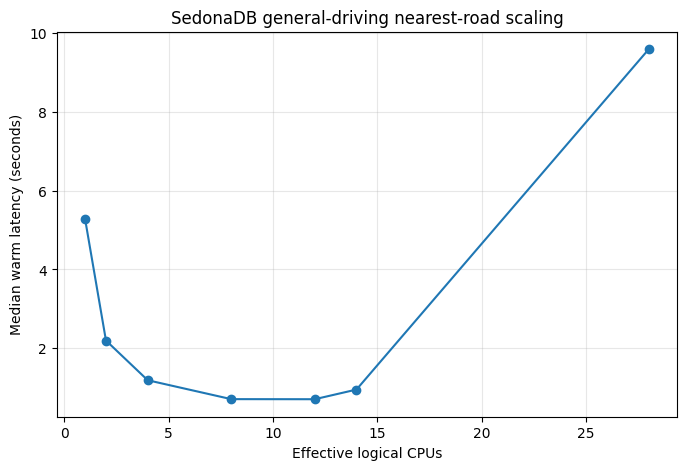

In [4]:
axis = scaling.plot(
    x="cpu_count",
    y="median_seconds",
    marker="o",
    legend=False,
    figsize=(8, 5),
)
axis.set_title("SedonaDB general-driving nearest-road scaling")
axis.set_xlabel("Effective logical CPUs")
axis.set_ylabel("Median warm latency (seconds)")
axis.grid(True, alpha=0.3)
plt.show()

## Cross-engine interpretation

The full-resource comparison answers: “How did these two deployed systems
perform on this fixed canonical workload?” It does not isolate software from
hardware. Kinetica GPU telemetry and Sedona CPU affinity must remain beside
the latency table.

In [5]:
headline = summary[summary.road_tier == "general_driving"][
    [
        "engine",
        "cpu_count",
        "location_count",
        "median_seconds",
        "p95_seconds",
        "throughput_locations_s",
    ]
]
display(headline)

,engine,cpu_count,location_count,median_seconds,p95_seconds,throughput_locations_s
2,kinetica,28,10000,0.958138,0.967242,10436.906100
3,sedonadb,1,10000,5.281617,5.323708,1893.359478
4,sedonadb,2,10000,2.195507,2.222038,4554.757379
5,sedonadb,4,10000,1.186705,1.212273,8426.696602
6,sedonadb,8,10000,0.706329,0.764672,14157.714069
7,sedonadb,12,10000,0.704221,0.722502,14200.087093
8,sedonadb,14,10000,0.949527,1.275740,10531.562692
9,sedonadb,28,10000,9.595626,16.248977,1042.141486


In [6]:
best_physical = scaling[scaling.cpu_count <= 14].sort_values(
    "median_seconds"
).iloc[0]
kinetica = headline[headline.engine == "kinetica"].iloc[0]
print(
    "Best Sedona physical-core median:",
    f"{best_physical.median_seconds:.3f}s on {best_physical.cpu_count} CPUs",
)
print(
    "Kinetica unrestricted median:",
    f"{kinetica.median_seconds:.3f}s",
)
print(
    "Sedona advantage at its best physical setting:",
    f"{kinetica.median_seconds / best_physical.median_seconds:.2f}x",
)

Best Sedona physical-core median: 0.704s on 12 CPUs
Kinetica unrestricted median: 0.958s
Sedona advantage at its best physical setting: 1.36x


The 28-thread Sedona row remains in the table even when flagged. Its high
relative MAD is a result to explain, not an outlier to delete. This distinction
also prevents the best physical-core number from being mislabeled as the
deployed full-resource comparison.

**Final checks**

- all expected cases and five measured repetitions exist;
- canonical checksums match;
- correctness reports zero unexplained mismatches;
- preparation and cold time are not in the warm headline;
- plot title, axes, units, and hardware labels describe the actual metric.